In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
hp=pd.read_csv("/content/Healthcare_patients_data")
hp

,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,1,2022-01-01 00:00:00,31-45,Male,West,General Medicine,Medication,Emergency,5.8,59151.0,59.0,0.12
1,2,2022-01-01 01:00:00,60+,Female,West,Orthopedics,Surgery,Routine,5.1,30272.0,97.0,0.11
2,3,2022-01-01 02:00:00,46-60,Male,South,Pediatrics,Observation,Routine,7.9,67498.0,60.0,0.19
3,4,2022-01-01 03:00:00,31-45,Female,North,Neurology,Medication,Routine,5.0,29896.0,51.0,0.47
4,5,2022-01-01 04:00:00,18-30,Female,North,Neurology,Therapy,Routine,0.0,36208.0,60.0,0.40
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2022-07-28 03:00:00,60+,Male,North,Cardiology,Observation,Routine,2.0,52402.0,54.0,0.54
4996,4997,2022-07-28 04:00:00,18-30,Female,North,Neurology,Surgery,Emergency,3.6,63973.0,58.0,0.39
4997,4998,2022-07-28 05:00:00,31-45,Male,North,Cardiology,Observation,Routine,6.2,38100.0,89.0,0.25
4998,4999,2022-07-28 06:00:00,46-60,Female,West,Neurology,Surgery,Emergency,4.0,66931.0,66.0,0.28


In [ ]:
hp.columns

Index(['patient_id', 'visit_date', 'age_group', 'gender', 'region',
       'department', 'treatment_type', 'visit_type', 'length_of_stay_days',
       'treatment_cost', 'recovery_score', 'readmission_risk'],
      dtype='object')

### Q1. How many patient records and columns are present in the dataset?

In [ ]:
hp.shape

(5000, 12)

### Q2. What are the data types of each column?

In [ ]:
hp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           5000 non-null   int64  
 1   visit_date           5000 non-null   object 
 2   age_group            5000 non-null   object 
 3   gender               5000 non-null   object 
 4   region               5000 non-null   object 
 5   department           5000 non-null   object 
 6   treatment_type       5000 non-null   object 
 7   visit_type           5000 non-null   object 
 8   length_of_stay_days  5000 non-null   float64
 9   treatment_cost       5000 non-null   float64
 10  recovery_score       5000 non-null   float64
 11  readmission_risk     5000 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 468.9+ KB


### Q3. Are there any missing values in the dataset?

In [ ]:
hp.isnull().sum()

,0
patient_id,0
visit_date,0
age_group,0
gender,0
region,0
department,0
treatment_type,0
visit_type,0
length_of_stay_days,0
treatment_cost,0


### Q4. Are there any duplicate records or duplicate patient IDs?


In [ ]:
hp.duplicated().sum()
hp['patient_id'].duplicated().sum()

np.int64(0)

### Q5. What are the unique categories present in the categorical columns?

In [ ]:
hp['department'].unique()
hp['treatment_type'].unique()
hp['visit_type'].unique()
hp['age_group'].unique()

array(['31-45', '60+', '46-60', '18-30'], dtype=object)

### Q6. What are the basic statistical characteristics of the numerical variables?

In [ ]:
hp.describe()

,patient_id,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,4.059660,54915.471800,74.718800,0.280966
std,1443.520003,1.928847,19481.160487,11.870481,0.157178
min,1.000000,0.000000,746.000000,33.000000,0.010000
25%,1250.750000,2.700000,41244.750000,67.000000,0.160000
50%,2500.500000,4.000000,55123.500000,75.000000,0.260000
75%,3750.250000,5.400000,68012.000000,83.000000,0.380000
max,5000.000000,11.900000,119307.000000,100.000000,0.840000


### Q7. Are the data types appropriate for analysis?

In [ ]:
hp['visit_date'] = pd.to_datetime(hp['visit_date'])
hp.dtypes

,0
patient_id,int64
visit_date,datetime64[ns]
age_group,object
gender,object
region,object
department,object
treatment_type,object
visit_type,object
length_of_stay_days,float64
treatment_cost,float64


### Q8. Are there invalid or unusual values in the numerical columns?

In [ ]:
min=hp['length_of_stay_days'].min()
min
max=hp['length_of_stay_days'].max()
max


11.9

In [ ]:

hp[['treatment_cost', 'recovery_score', 'readmission_risk']].describe()

,treatment_cost,recovery_score,readmission_risk
count,5000.000000,5000.000000,5000.000000
mean,54915.471800,74.718800,0.280966
std,19481.160487,11.870481,0.157178
min,746.000000,33.000000,0.010000
25%,41244.750000,67.000000,0.160000
50%,55123.500000,75.000000,0.260000
75%,68012.000000,83.000000,0.380000
max,119307.000000,100.000000,0.840000




### Q9. How do patient visits vary by month and day of the week?

In [ ]:
year=hp['year'] = hp['visit_date'].dt.year
year
month=hp['month'] = hp['visit_date'].dt.month
month
m_name=hp['month_name'] = hp['visit_date'].dt.month_name()
m_name
day=hp['day_of_week'] = hp['visit_date'].dt.day_name()
day

,visit_date
0,Saturday
1,Saturday
2,Saturday
3,Saturday
4,Saturday
...,...
4995,Thursday
4996,Thursday
4997,Thursday
4998,Thursday


### Q10. How can patients be categorized based on readmission risk?

In [ ]:
import numpy as np

conditions = [
    hp['readmission_risk'] < 0.30,
    hp['readmission_risk'].between(0.30, 0.50),
    hp['readmission_risk'] >= 0.50
]

choices = ['Low Risk', 'Moderate Risk', 'High Risk']

hp['risk_category'] = np.select(conditions, choices, default='Unknown')
risk_category=hp['risk_category'].value_counts()
risk_category


,count
risk_category,
Low Risk,2900
Moderate Risk,1635
High Risk,465


### Q11. Which departments have the highest patient volume?

In [ ]:
hp.groupby('department')['patient_id'].count().sort_values(
    ascending=False
)

,patient_id
department,
Orthopedics,1058
Cardiology,995
General Medicine,991
Pediatrics,989
Neurology,967


### Q12. Which departments have the highest average treatment cost?

In [ ]:
hp.groupby('department')['treatment_cost'].mean().sort_values(
    ascending=False
)

,treatment_cost
department,
Neurology,55761.751810
Cardiology,55632.595980
Orthopedics,54912.558601
Pediatrics,54781.584429
General Medicine,53506.395560



### Q13. Which departments have the highest average recovery score?

In [ ]:
hp.groupby('department')['recovery_score'].mean().sort_values(
    ascending=False
)

,recovery_score
department,
Neurology,75.179938
Orthopedics,74.959357
General Medicine,74.774975
Pediatrics,74.523761
Cardiology,74.152764


### Q14. Which departments have the highest readmission risk?

In [ ]:
hp.groupby('department')['readmission_risk'].mean().sort_values(
    ascending=False
)

,readmission_risk
department,
Neurology,0.283744
Pediatrics,0.282305
General Medicine,0.281968
Orthopedics,0.278771
Cardiology,0.278271


### Q15. Which treatment types are associated with higher average costs and recovery scores?

In [ ]:
treatment_analysis = hp.groupby('treatment_type').agg(
    patient_count=('patient_id', 'count'),
    avg_cost=('treatment_cost', 'mean'),
    avg_recovery=('recovery_score', 'mean'),
    avg_risk=('readmission_risk', 'mean')
).round(2)

treatment_analysis

,patient_count,avg_cost,avg_recovery,avg_risk
treatment_type,,,,
Medication,1236,55112.26,74.55,0.28
Observation,1270,54958.33,74.81,0.28
Surgery,1262,55327.28,74.70,0.28
Therapy,1232,54252.04,74.81,0.28


### Q16. Which visit type has the highest average length of stay and readmission risk?


In [ ]:
hp.groupby('visit_type').agg(
    avg_length_of_stay=('length_of_stay_days', 'mean'),
    avg_readmission_risk=('readmission_risk', 'mean')
).round(2)

,avg_length_of_stay,avg_readmission_risk
visit_type,,
Emergency,4.10,0.28
Routine,4.04,0.28


### DEPARTMENT SUMMARY

In [ ]:
department_summary = hp.groupby('department').agg(
    total_visits=('patient_id', 'count'),
    avg_length_of_stay=('length_of_stay_days', 'mean'),
    avg_treatment_cost=('treatment_cost', 'mean'),
    total_treatment_cost=('treatment_cost', 'sum'),
    avg_recovery_score=('recovery_score', 'mean'),
    avg_readmission_risk=('readmission_risk', 'mean')
).round(2)

department_summary

,total_visits,avg_length_of_stay,avg_treatment_cost,total_treatment_cost,avg_recovery_score,avg_readmission_risk
department,,,,,,
Cardiology,995,4.03,55632.60,55354433.0,74.15,0.28
General Medicine,991,4.07,53506.40,53024838.0,74.77,0.28
Neurology,967,4.06,55761.75,53921614.0,75.18,0.28
Orthopedics,1058,4.01,54912.56,58097487.0,74.96,0.28
Pediatrics,989,4.14,54781.58,54178987.0,74.52,0.28


### Q17. Which age group represents the largest share of patient visits?

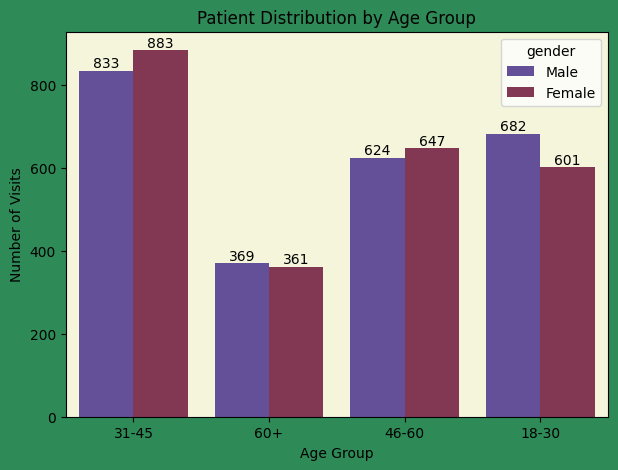

In [ ]:
plt.figure(facecolor='seagreen',figsize=(7,5))
count=sns.countplot(data=hp, x='age_group',hue='gender', palette='twilight',width=0.8)
plt.title('Patient Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Visits')
plt.gca().set_facecolor('beige')


for i in count.containers:
  count.bar_label(i)



### Q18. What is the distribution of patient visits by gender?

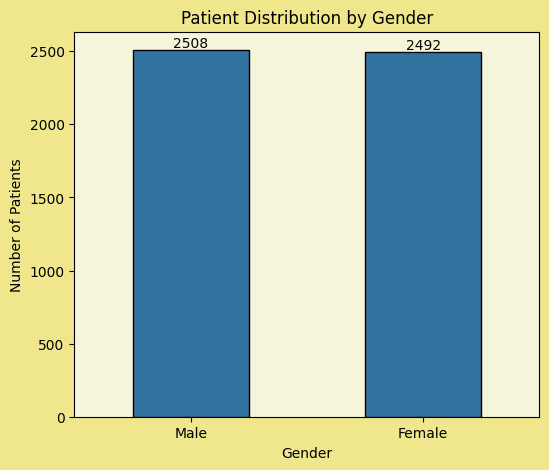

In [30]:
plt.figure(facecolor='khaki' ,figsize=(6, 5))

count=sns.countplot(
    data=hp,
    x='gender',
    edgecolor='black',
    linewidth=1,
    width= 0.5

)

plt.title('Patient Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.gca().set_facecolor('beige')

for i in count.containers:
  count.bar_label(i)


### Q19. Which regions contribute the most patient visits?

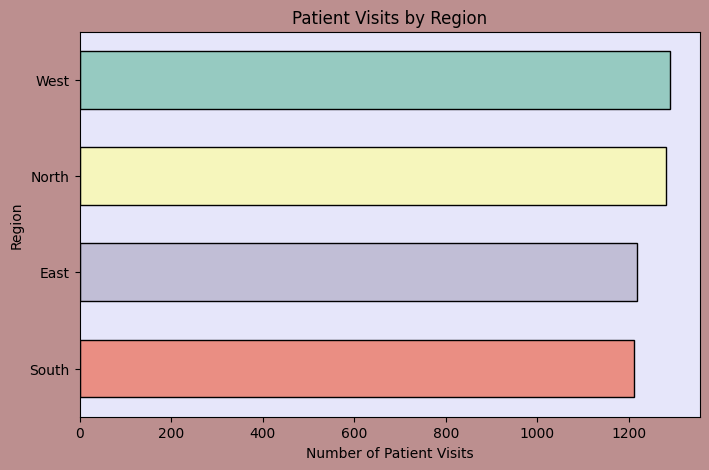

In [ ]:
region_counts = (
    hp['region']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(facecolor='rosybrown',figsize=(8, 5))

sns.barplot(
    x=region_counts.values,
    y=region_counts.index,
    hue=region_counts.index,
    palette='Set3',
    edgecolor='black',
    linewidth=1,
    estimator='sum',
    width=0.6

)

plt.title('Patient Visits by Region')
plt.xlabel('Number of Patient Visits')
plt.ylabel('Region')
plt.gca().set_facecolor('lavender')
plt.show()

### Q20.Which hospital departments handle the highest number of patient visits?

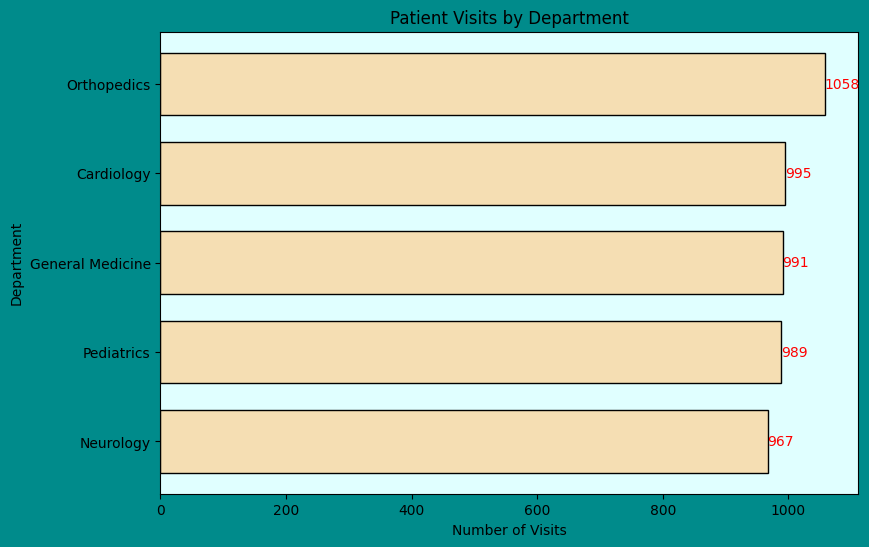

In [ ]:
department_counts = (
    hp['department']
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure( facecolor='darkcyan', figsize=(9, 6))

bar=plt.barh(
    department_counts.index,
    department_counts.values,
    color='wheat',
    edgecolor='black',
    linewidth=1,
    height=0.7
)

plt.title('Patient Visits by Department')
plt.xlabel('Number of Visits')
plt.ylabel('Department')
plt.gca().set_facecolor('lightcyan')
plt.gca().bar_label(bar, color='r')
plt.show()


### Q21. What proportion of patient visits are emergency, routine, or other types?

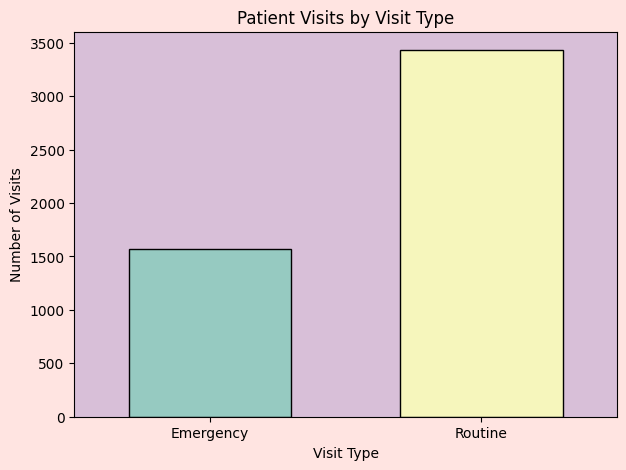

In [ ]:
plt.figure(facecolor='mistyrose',figsize=(7, 5))

sns.countplot(
    data=hp,
    x='visit_type',
    hue='visit_type',
    palette='Set3',
    edgecolor='black',
    linewidth=1,
    width=0.6
)

plt.title('Patient Visits by Visit Type')
plt.xlabel('Visit Type')
plt.ylabel('Number of Visits')
plt.gca().set_facecolor('thistle')
plt.show()

###Q22. Which treatment types have the highest average treatment cost?

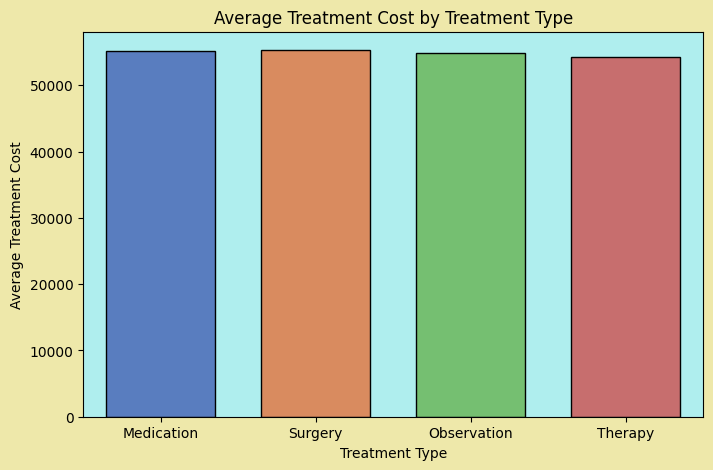

In [ ]:
plt.figure(facecolor='palegoldenrod',figsize=(8, 5))

sns.barplot(
    data=hp,
    x='treatment_type',
    y='treatment_cost',
    hue='treatment_type',
    palette='muted',
    edgecolor='black',
    linewidth=1,
    estimator='mean',
    errorbar=None,
    width=0.7
)

plt.title('Average Treatment Cost by Treatment Type')
plt.xlabel('Treatment Type')
plt.ylabel('Average Treatment Cost')
plt.gca().set_facecolor('paleturquoise')
plt.show()

### Q23. How are treatment costs distributed across patient visits?

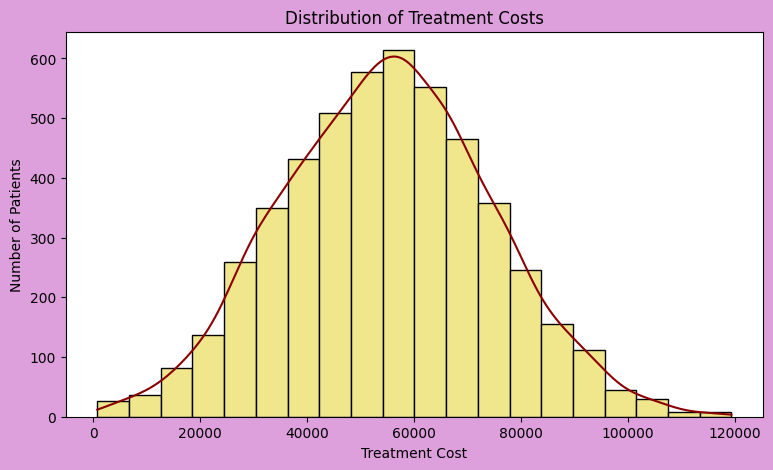

In [ ]:
plt.figure(facecolor='plum',figsize=(9, 5))

sns.histplot(
    data=hp,
    x='treatment_cost',
    kde=True,
    facecolor='khaki',
    alpha=0.7,
    color='darkred',
    edgecolor='black',
    linewidth=1,
    bins=20
)

plt.title('Distribution of Treatment Costs')
plt.xlabel('Treatment Cost')
plt.ylabel('Number of Patients')
plt.show()

###Q24.Which departments have the highest average readmission risk?

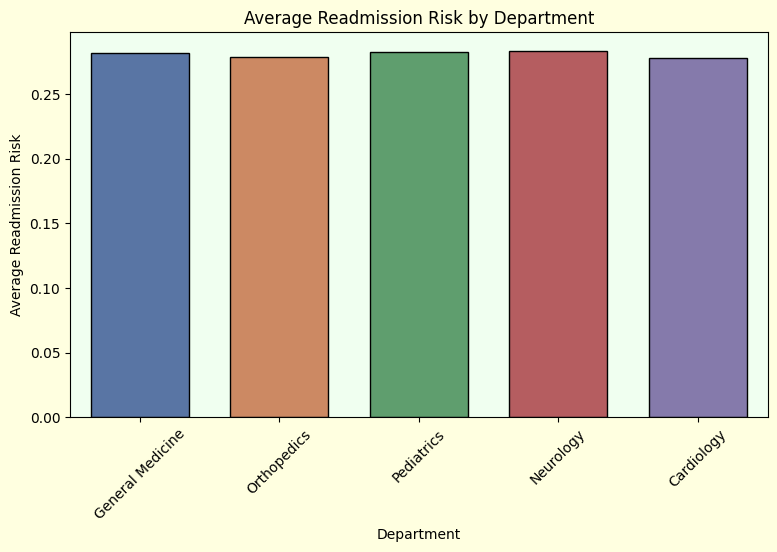

In [ ]:
plt.figure(facecolor='lightyellow',figsize=(9, 5))

sns.barplot(
    data=hp,
    x='department',
    y='readmission_risk',
    hue='department',
    palette='deep',
    edgecolor='black',
    linewidth=1,
    estimator='mean',
    errorbar=None,
    width=0.7
)

plt.title('Average Readmission Risk by Department')
plt.xlabel('Department')
plt.ylabel('Average Readmission Risk')
plt.xticks(rotation=45)
plt.gca().set_facecolor('honeydew')
plt.show()

### Q25.Is a longer hospital stay associated with higher treatment costs?

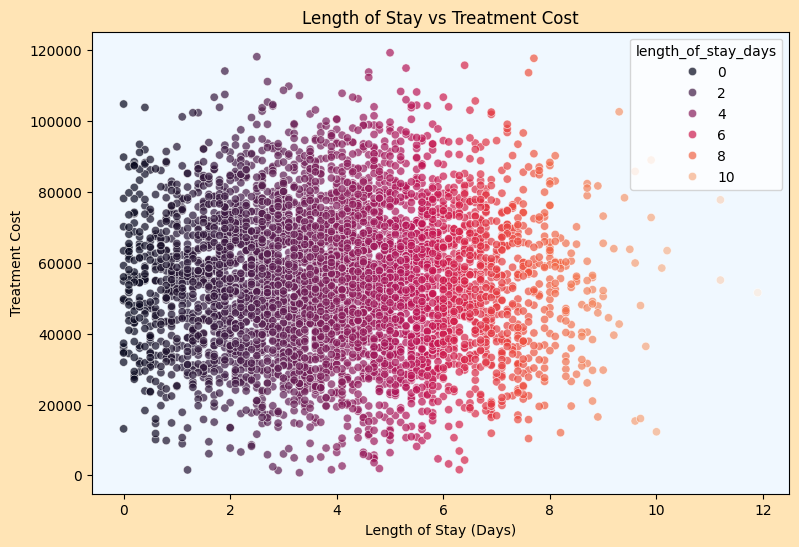

In [ ]:
plt.figure(facecolor='moccasin',figsize=(9, 6))

sns.scatterplot(
    data=hp,
    x='length_of_stay_days',
    y='treatment_cost',
    hue='length_of_stay_days',
    palette='rocket',
    alpha=0.7
)

plt.title('Length of Stay vs Treatment Cost')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Treatment Cost')
plt.gca().set_facecolor('aliceblue')
plt.show()

In [ ]:
hp[
    ['length_of_stay_days', 'treatment_cost']
].corr()

,length_of_stay_days,treatment_cost
length_of_stay_days,1.000000,-0.022281
treatment_cost,-0.022281,1.000000


### Q26.Is there a relationship between patient recovery score and readmission risk?

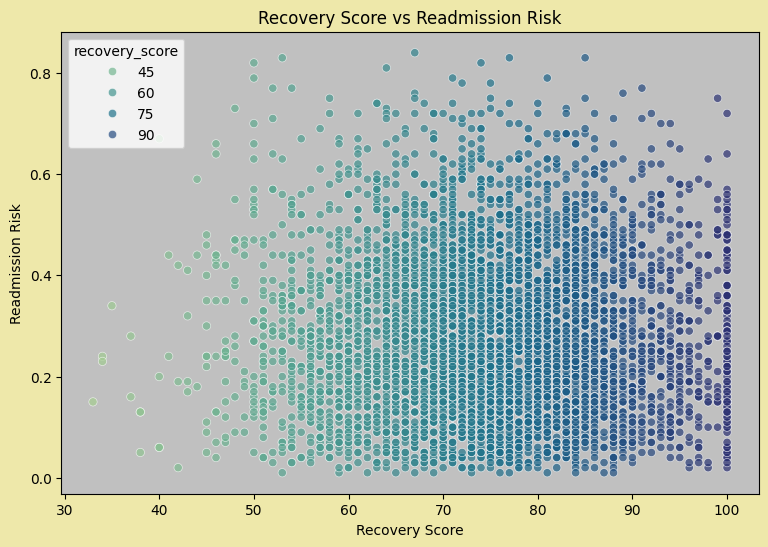

In [ ]:
plt.figure(facecolor='palegoldenrod',figsize=(9, 6))

sns.scatterplot(
    data=hp,
    x='recovery_score',
    y='readmission_risk',
    hue='recovery_score',
    palette='crest',
    alpha=0.7
)

plt.title('Recovery Score vs Readmission Risk')
plt.xlabel('Recovery Score')
plt.ylabel('Readmission Risk')
plt.gca().set_facecolor('silver')
plt.show()

###Q27. How does patient volume change over time?

In [ ]:
hp['visit_month'] = hp['visit_date'].dt.to_period('M')

In [ ]:
monthly_visits = (
    hp.groupby('visit_month')['patient_id']
    .count()
    .reset_index()
)

monthly_visits['visit_month'] = (
    monthly_visits['visit_month'].astype(str)
)

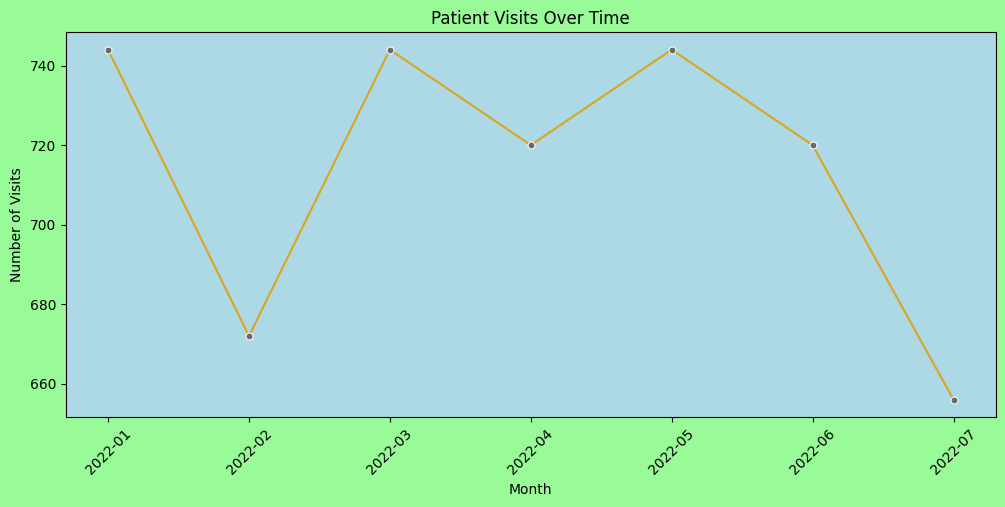

In [ ]:
plt.figure(facecolor='palegreen',figsize=(12, 5))

sns.lineplot(
    data=monthly_visits,
    x='visit_month',
    y='patient_id',
    marker='o',
    color='goldenrod',
    markersize=5,
    markerfacecolor='dimgrey'

)

plt.title('Patient Visits Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.gca().set_facecolor('lightblue')
plt.show()